# Meme Overlay Caption Script

This notebook creates a high-quality meme image overlayed with caption

**Inputs:** 
- Image path (for the moment hardcoded to 0000.jpg from raw humanface)
- Caption string (for the moment hardcoded for testing)

**Output:** 
- High-quality JPG file (256x256) saved in assets folder
- Display in notebook for verification

In [1]:
# Import required libraries
from PIL import Image, ImageDraw, ImageFont
import textwrap
import os
from IPython.display import display

In [2]:
# Configuration
INPUT_IMAGES_DIR = "../assets/raw_humanface"
OUTPUT_IMAGES_DIR = "../assets/memes"
MEME_SIZE = (256, 256)  # Output size to match input

# Hardcoded test caption
TEST_CAPTION_TOP = "HE WAS A LONG TIME"
TEST_CAPTION_BOTTOM = "FRIEND OF MINE"

# Create output directory
os.makedirs(OUTPUT_IMAGES_DIR, exist_ok=True)
print(f"Output directory ready: {OUTPUT_IMAGES_DIR}")

# Use specific first image (0000.jpg)
SELECTED_IMAGE = os.path.join(INPUT_IMAGES_DIR, "0000.jpg")
if not os.path.exists(SELECTED_IMAGE):
    raise ValueError(f"Image {SELECTED_IMAGE} not found. Please run 1a_image_acquisition.ipynb first.")

print(f"Using image: {SELECTED_IMAGE}")

Output directory ready: ../assets/memes
Using image: ../assets/raw_humanface/0000.jpg


In [3]:
def create_meme_direct_pil(image_path, top_text="", bottom_text="", output_path="meme.jpg", size=(256, 256)):
    """
    Create meme directly with PIL for reliable text rendering.
    
    Args:
        image_path (str): Path to input image
        top_text (str): Text for top of meme
        bottom_text (str): Text for bottom of meme  
        output_path (str): Path for output image
        size (tuple): Output image size (width, height)
    
    Returns:
        PIL.Image: The created meme image
    """
    # Load and resize image
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size, Image.Resampling.LANCZOS)

    draw = ImageDraw.Draw(img)
    width, height = img.size

    # Calculate font size based on image size
    font_size = int(width * 0.09)
    outline_width = max(2, font_size // 15)

    # Load font with proper fallbacks
    font = None
    font_paths = [
        "impact.ttf", "Impact.ttf", "IMPACT.TTF",
        "arial.ttf", "Arial.ttf", "arialbd.ttf",
        "/System/Library/Fonts/Impact.ttf",  # macOS
        "/Windows/Fonts/impact.ttf",  # Windows
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"  # Linux
    ]

    for font_path in font_paths:
        try:
            font = ImageFont.truetype(font_path, size=font_size)
            print(f"Using font: {font_path}")
            break
        except IOError:
            continue

    if font is None:
        font = ImageFont.load_default()
        print("Using default font")

    def draw_meme_text(text, y_position):
        """Helper function to draw outlined text"""
        text = text.upper()
        text_bbox = draw.textbbox((0, 0), text, font=font)
        text_width = text_bbox[2] - text_bbox[0]
        x = (width - text_width) / 2

        # Draw black outline
        for dx in range(-outline_width, outline_width + 1):
            for dy in range(-outline_width, outline_width + 1):
                if dx != 0 or dy != 0:
                    draw.text((x + dx, y_position + dy), text, font=font, fill="black")

        # Draw white text
        draw.text((x, y_position), text, font=font, fill="white")

    def draw_wrapped_text(text, y_position, is_bottom=False):
        text = text.upper()
        
        # --- Remove trailing punctuation from bottom text ---
        if is_bottom and text.endswith(('.', ',', '!', '?')):
            text = text[:-1]

        # --- Automatically wrap text ---
        # Character width is roughly half the font size
        char_width_ratio = 1.8 
        chars_per_line = int(width / (font_size / char_width_ratio))
        lines = textwrap.wrap(text, width=chars_per_line)
        
        line_height = font.getbbox('A')[3] + font_size // 4

        # Adjust starting y_position for multi-line bottom text
        if is_bottom:
            y_position -= (len(lines) - 1) * line_height

        for line in lines:
            # Get text size for centering
            line_bbox = draw.textbbox((0, 0), line, font=font)
            line_width = line_bbox[2] - line_bbox[0]
            x = (width - line_width) / 2
            
            # Draw outline
            for dx in range(-outline_width, outline_width + 1):
                for dy in range(-outline_width, outline_width + 1):
                    if dx != 0 or dy != 0:
                        draw.text((x + dx, y_position + dy), line, font=font, fill="black")
            
            # Draw main text
            draw.text((x, y_position), line, font=font, fill="white")
            y_position += line_height # Move to the next line

    # Draw top text
    if top_text:
        # draw_meme_text(top_text, font_size // 2)
        draw_wrapped_text(top_text, y_position=(font_size // 2))

    # Draw bottom text
    if bottom_text:
        # text_bbox = draw.textbbox((0, 0), bottom_text.upper(), font=font)
        text_bbox = draw.textbbox((0, 0), "A", font=font)
        text_height = text_bbox[3] - text_bbox[1]
        # draw_meme_text(bottom_text, height - text_height - font_size // 2)
        initial_y = height - text_height - (font_size // 2)
        draw_wrapped_text(bottom_text, y_position=initial_y, is_bottom=True)

    # Save with high quality
    img.save(output_path, "JPEG", quality=98, optimize=True)
    print(f"Meme created and saved: {output_path}")
    return img

In [4]:
# Create meme using direct PIL method
print(f"Creating meme from: {SELECTED_IMAGE}")
print(f"Top text: '{TEST_CAPTION_TOP}'")
print(f"Bottom text: '{TEST_CAPTION_BOTTOM}'")
print(f"Output size: {MEME_SIZE}")

# Execute meme creation
output_filename = "meme.jpg"
output_path = os.path.join(OUTPUT_IMAGES_DIR, output_filename)

meme_image = create_meme_direct_pil(
    image_path=SELECTED_IMAGE,
    top_text=TEST_CAPTION_TOP,
    bottom_text=TEST_CAPTION_BOTTOM,
    output_path=output_path,
    size=MEME_SIZE
)

Creating meme from: ../assets/raw_humanface/0000.jpg
Top text: 'HE WAS A LONG TIME'
Bottom text: 'FRIEND OF MINE'
Output size: (256, 256)
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme.jpg


Generated Meme:


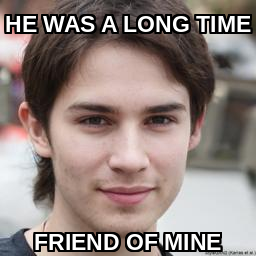


Verification:
File saved at: ../assets/memes/meme.jpg
File exists: True
File size: 24,726 bytes (24.1 KB)
Image dimensions: (256, 256)
Image format: JPEG
Image mode: RGB

Meme saved in: ../assets/memes


In [5]:
# Display the created meme
print("Generated Meme:")
display(meme_image)

# Verification
print(f"\nVerification:")
print(f"File saved at: {output_path}")
print(f"File exists: {os.path.exists(output_path)}")
if os.path.exists(output_path):
    file_size = os.path.getsize(output_path)
    print(f"File size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
    
    # Verify image properties
    verify_img = Image.open(output_path)
    print(f"Image dimensions: {verify_img.size}")
    print(f"Image format: {verify_img.format}")
    print(f"Image mode: {verify_img.mode}")

print(f"\nMeme saved in: {OUTPUT_IMAGES_DIR}")

In [6]:
# --- MOOD-BASED DYNAMIC CAPTION TESTING ---
# This section integrates the mood-based caption generation from 2b_caption_generation.ipynb

print("=" * 60)
print("MOOD-BASED DYNAMIC CAPTION GENERATION TEST")
print("=" * 60)

# Import required packages for caption generation
import pandas as pd
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel, pipeline
import sys
import warnings
warnings.filterwarnings('ignore')

# Add helpers to path and import caption generation functions
sys.path.append("../helpers")
import caption_helpers as helpers

print("Setting up mood-based caption generation...")

# Load the fine-tuned model
def load_fine_tuned_model(model_path="../models/gpt2-mood-caption-v2"):
    """Load the fine-tuned GPT-2 model and tokenizer."""
    print(f"Loading fine-tuned model from: {model_path}")
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found at {model_path}. Please run 2a_nlp_model_setup.ipynb first.")
    
    try:
        model = GPT2LMHeadModel.from_pretrained(model_path)
        tokenizer = GPT2Tokenizer.from_pretrained(model_path)
        
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        generator = pipeline(
            "text-generation",
            model=model,
            tokenizer=tokenizer,
            device=0 if torch.cuda.is_available() else -1
        )
        
        print("Fine-tuned model loaded successfully!")
        return model, tokenizer, generator
        
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        raise e

# Load the model
try:
    fine_tuned_model, fine_tuned_tokenizer, fine_tuned_generator = load_fine_tuned_model()
    model_loaded = True
    print("Model ready for mood-based caption generation!")
except Exception as e:
    print(f"Could not load model: {e}")
    print("Falling back to mock captions for demonstration...")
    fine_tuned_generator = None
    model_loaded = False

print("\n" + "=" * 40)


MOOD-BASED DYNAMIC CAPTION GENERATION TEST


2025-07-20 17:41:56.698182: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-20 17:41:56.698245: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-20 17:41:56.698278: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-20 17:41:56.706937: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Device set to use cpu


Setting up mood-based caption generation...
Loading fine-tuned model from: ../models/gpt2-mood-caption-v2
Fine-tuned model loaded successfully!
Model ready for mood-based caption generation!



TESTING DIFFERENT MOODS WITH DYNAMIC CAPTIONS

--- Testing Mood: JOY ---
Generating caption for mood: joy...
Generated TOP: 'THE BATTLE CRACKS BACK'
Generated BOTTOM: 'HAPPENED'
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_joy_01.jpg
Displaying mood-based meme (joy):


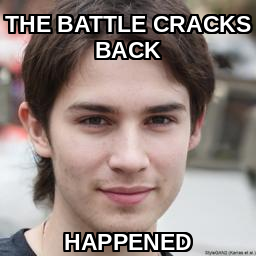

Saved as: meme_joy_01.jpg
----------------------------------------

--- Testing Mood: SADNESS ---
Generating caption for mood: sadness...
Generated TOP: 'I HAVE BADLY HONESTED'
Generated BOTTOM: 'NO'
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_sadness_02.jpg
Displaying mood-based meme (sadness):


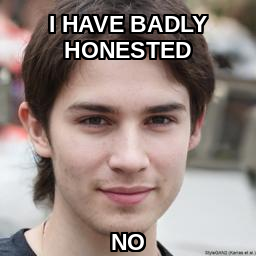

Saved as: meme_sadness_02.jpg
----------------------------------------

--- Testing Mood: ANGER ---
Generating caption for mood: anger...
Generated TOP: 'YOU WERE LYING'
Generated BOTTOM: 'THE'
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_anger_03.jpg
Displaying mood-based meme (anger):


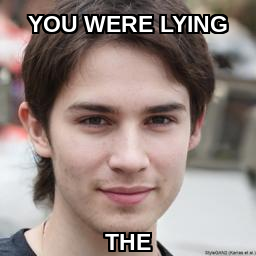

Saved as: meme_anger_03.jpg
----------------------------------------

--- Testing Mood: SURPRISE ---
Generating caption for mood: surprise...
Generated TOP: 'OH'
Generated BOTTOM: 'THE DOGS ARE IN'
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_surprise_04.jpg
Displaying mood-based meme (surprise):


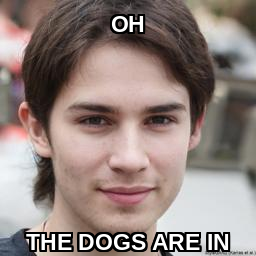

Saved as: meme_surprise_04.jpg
----------------------------------------

--- Testing Mood: LOVE ---
Generating caption for mood: love...
Generated TOP: 'I LOVE THIS SHOW'
Generated BOTTOM: ''
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_love_05.jpg
Displaying mood-based meme (love):


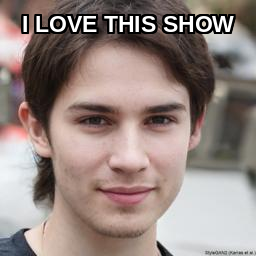

Saved as: meme_love_05.jpg
----------------------------------------

--- Testing Mood: FEAR ---
Generating caption for mood: fear...
Generated TOP: 'THE FACT THAT I AM A'
Generated BOTTOM: ''
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: ../assets/memes/meme_fear_06.jpg
Displaying mood-based meme (fear):


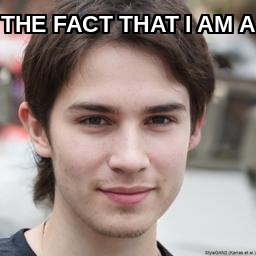

Saved as: meme_fear_06.jpg
----------------------------------------

All mood-based memes created and saved in: ../assets/memes
This demonstrates dynamic caption generation instead of fixed text!


In [7]:
# Test different moods and create memes with dynamic captions
print("TESTING DIFFERENT MOODS WITH DYNAMIC CAPTIONS")
print("=" * 50)

# Define test moods to demonstrate the system
test_moods = ["joy", "sadness", "anger", "surprise", "love", "fear"]

# Function to generate mood-based caption (with fallback for demonstration)
def generate_mood_caption(mood, generator=None):
    """Generate caption for given mood, with fallback for demo purposes."""
    if model_loaded and generator:
        # Use the actual fine-tuned model
        result = helpers.generate_meme_caption(mood, generator, "fine_tuned")
        return result["top_text"], result["bottom_text"]
    else:
        # Fallback mock captions for demonstration when model isn't available
        mock_captions = {
            "joy": ("I'M SO HAPPY", "TODAY IS GREAT"),
            "sadness": ("FEELING DOWN", "BUT STILL TRYING"),
            "anger": ("THIS IS ANNOYING", "NEED TO CALM DOWN"),
            "surprise": ("WHOA DIDN'T SEE", "THAT COMING"),
            "love": ("YOU'RE AMAZING", "FEELING THE LOVE"),
            "fear": ("THIS IS SCARY", "BUT I'LL BE BRAVE")
        }
        return mock_captions.get(mood, ("UNKNOWN MOOD", "TRY ANOTHER"))

# Create memes for each test mood
for i, mood in enumerate(test_moods):
    print(f"\n--- Testing Mood: {mood.upper()} ---")
    
    # Generate dynamic caption based on mood
    if model_loaded:
        print(f"Generating caption for mood: {mood}...")
        top_text, bottom_text = generate_mood_caption(mood, fine_tuned_generator)
    else:
        print(f"Using mock caption for mood: {mood}...")
        top_text, bottom_text = generate_mood_caption(mood)
    
    print(f"Generated TOP: '{top_text}'")
    print(f"Generated BOTTOM: '{bottom_text}'")
    
    # Create meme with dynamic caption
    output_filename = f"meme_{mood}_{i+1:02d}.jpg"
    output_path = os.path.join(OUTPUT_IMAGES_DIR, output_filename)
    
    meme_image = create_meme_direct_pil(
        image_path=SELECTED_IMAGE,
        top_text=top_text,
        bottom_text=bottom_text,
        output_path=output_path,
        size=MEME_SIZE
    )
    
    # Display the generated meme
    print(f"Displaying mood-based meme ({mood}):")
    display(meme_image)
    
    print(f"Saved as: {output_filename}")
    print("-" * 40)

print(f"\nAll mood-based memes created and saved in: {OUTPUT_IMAGES_DIR}")
print("This demonstrates dynamic caption generation instead of fixed text!")
